In [1]:
import numpy as np, scipy.io as sio
from matplotlib import pyplot as plt
import pandas as pd
from sympy import hn1

from src.buffer_dynamics import simulate_buffer, plot_buffer_levels, find_max_fps, plot_stall_vs_fps, plot_stall_vs_fps_multi
from src.commons.io import load_hn, load_rd
from src.plotting.plotting_utils import plot_traces, plot_qp_sizes
from src.plotting.viewport import build_fov_traces, aggregate_traces


In [2]:
hmd = load_hn('datasets/navigation/hn.mat')
rd = load_rd('datasets/navigation/rd.mat')

bitrate = rd['bitrate']  # length-15 list, each (7, 64, N)
ymse = rd['ymse']
bitdepth = rd['bitdepth']
qp_labels = [5, 10, 15, 20, 25, 30, 35]  # example QP values
print(hmd[0].shape)

(34,)


In [3]:
video_id = 0
user_id = 0
pd.DataFrame(hmd[video_id][user_id]).head()


,0,1,2,3
0,-48.747200,-7.432520,3.842840,5.700000e-07
1,-0.000190,-3.716223,1.921415,3.500786e-02
2,-0.001341,-3.715703,1.921299,6.728675e-02
3,-0.004152,-3.714361,1.920745,1.025241e-01
4,-0.008139,-3.712591,1.919882,1.371408e-01


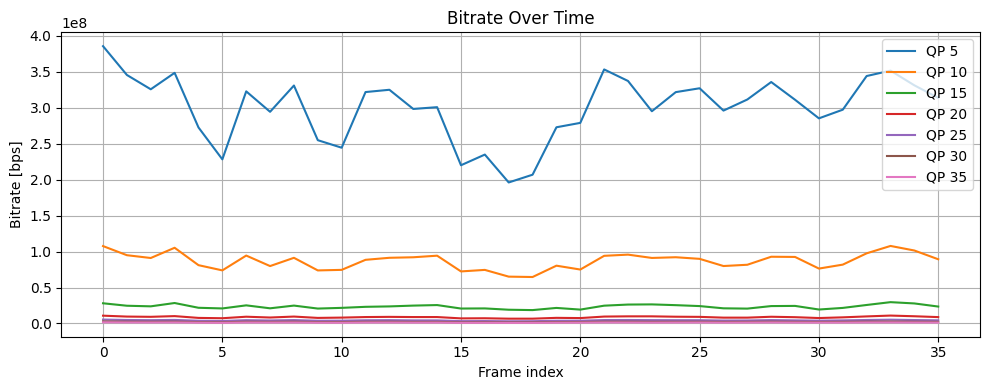

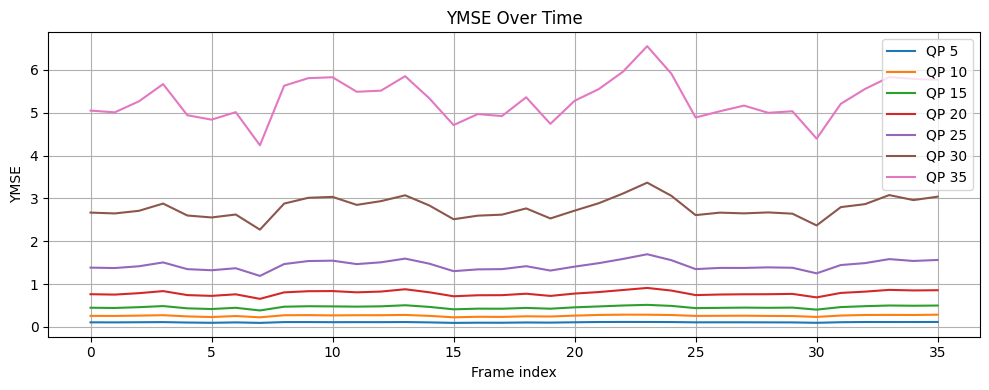

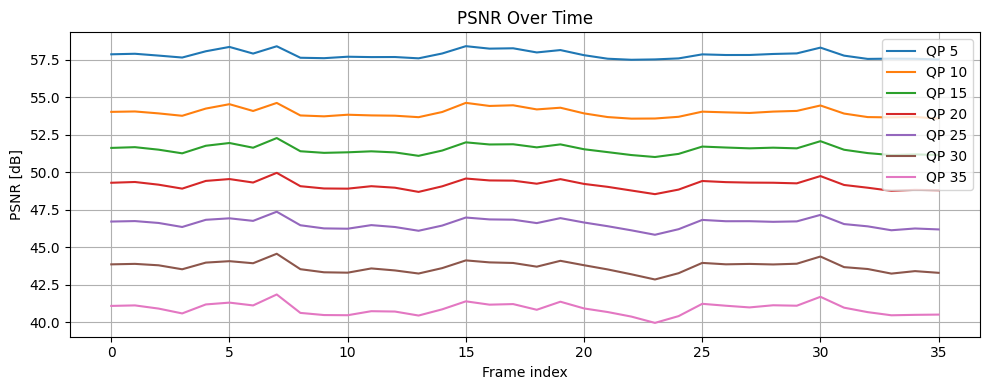

In [4]:


traces = build_fov_traces(bitrate[video_id], ymse[video_id], hmd[video_id][user_id], bitdepth[video_id])  # shape (7, N)
plot_traces(traces['bitrate'], qp_labels, ylabel='Bitrate [bps]', title='Bitrate Over Time')
plot_traces(traces['ymse'], qp_labels, ylabel='YMSE', title='YMSE Over Time')
plot_traces(traces['psnr'], qp_labels, ylabel='PSNR [dB]', title='PSNR Over Time')
plt.show()

In [24]:
video_traces = {}
for video_id in range(15):
    video_traces[video_id] = build_fov_traces(bitrate[video_id], ymse[video_id], hmd[video_id][user_id], bitdepth[video_id])
video_traces

{0: {'bitrate': array([[3.85378689e+08, 3.45351040e+08, 3.25468382e+08, 3.48306288e+08,
          2.72414866e+08, 2.28099866e+08, 3.22572077e+08, 2.94183244e+08,
          3.30689885e+08, 2.54729346e+08, 2.44272899e+08, 3.21604906e+08,
          3.24782233e+08, 2.98144774e+08, 3.00599541e+08, 2.19903883e+08,
          2.34734606e+08, 1.95992046e+08, 2.06758247e+08, 2.72677007e+08,
          2.78783132e+08, 3.53044042e+08, 3.37006458e+08, 2.94965022e+08,
          3.21507263e+08, 3.26874763e+08, 2.95854936e+08, 3.11266229e+08,
          3.35550009e+08, 3.10879402e+08, 2.85073241e+08, 2.97118162e+08,
          3.43884857e+08, 3.51378632e+08, 3.30948280e+08, 3.13496538e+08],
         [1.07563884e+08, 9.48892960e+07, 9.10118624e+07, 1.05225545e+08,
          8.10529960e+07, 7.37974184e+07, 9.43932896e+07, 7.97940131e+07,
          9.12628933e+07, 7.37504336e+07, 7.45218061e+07, 8.84834619e+07,
          9.13033861e+07, 9.20216627e+07, 9.42304723e+07, 7.23604907e+07,
          7.44761083e+0

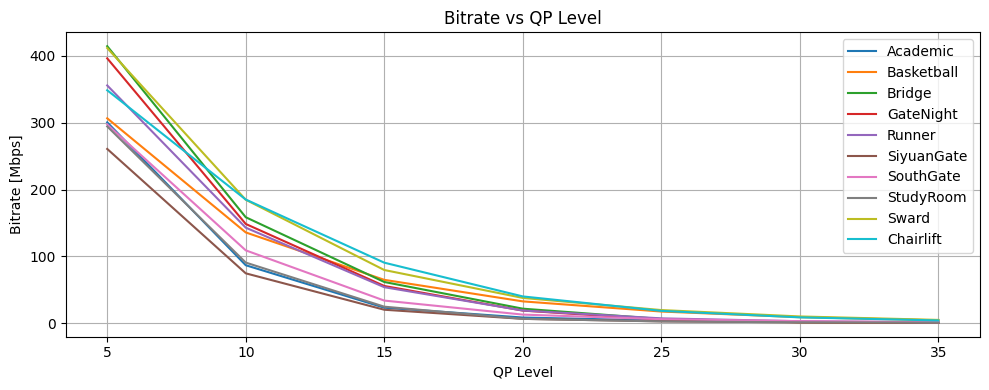

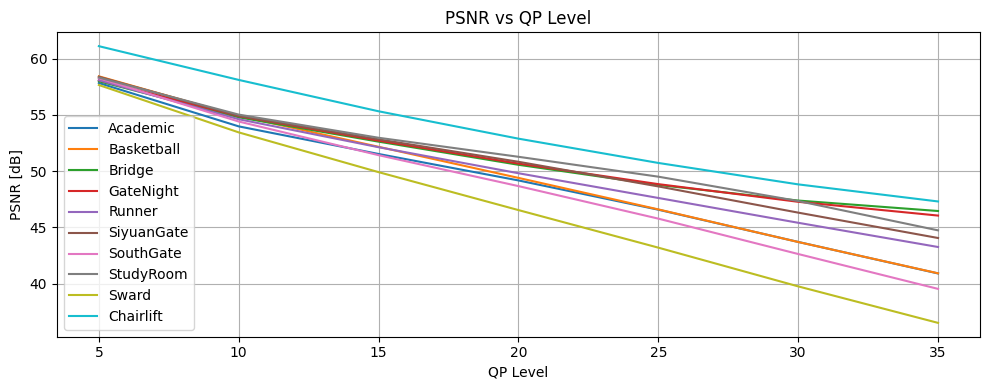

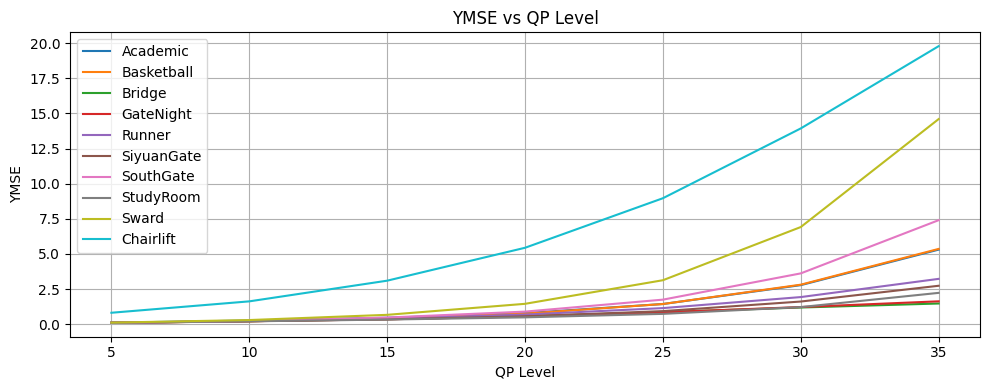

[array([0.10839549, 0.26177006, 0.45976915, 0.78958553, 1.4368376 ,
        2.78033912, 5.3070728 ]),
 array([0.09439669, 0.21042987, 0.39653502, 0.75140009, 1.43695289,
        2.8125445 , 5.35717451]),
 array([0.10443467, 0.21644992, 0.35588841, 0.57155339, 0.86381618,
        1.18798987, 1.47345458]),
 array([0.10195473, 0.2111142 , 0.348665  , 0.55767767, 0.84977587,
        1.22017142, 1.62815725]),
 array([0.1022472 , 0.22546207, 0.40066033, 0.68540906, 1.1456694 ,
        1.93094369, 3.22612699]),
 array([0.09631262, 0.21434915, 0.34857413, 0.55654937, 0.93178177,
        1.61349906, 2.73527382]),
 array([0.09871571, 0.2383036 , 0.47538467, 0.89658276, 1.74814459,
        3.6160086 , 7.40157876]),
 array([0.0969243 , 0.20542774, 0.33015242, 0.48845204, 0.73634966,
        1.21861201, 2.22982436]),
 array([ 0.11312096,  0.29621202,  0.6674572 ,  1.45058064,  3.12974926,
         6.9133987 , 14.5948636 ]),
 array([ 0.81495962,  1.62600928,  3.09715984,  5.43814314,  8.96376369,
  

In [25]:
video_names = ['Academic', 'Basketball', 'Bridge', 'GateNight', 'Runner',
               'SiyuanGate', 'SouthGate', 'StudyRoom', 'Sward', 'Chairlift',
               'Skateboard', 'Gaslamp', 'Harbor', 'KiteFlite', 'Trolley']

video_bitrates = [video_traces[i]['bitrate'] for i in range(len(video_traces))]
plot_qp_sizes(video_bitrates, video_names[:10], qp_labels, ylabel='Bitrate [Mbps]', title='Bitrate vs QP Level', dividing_factor=1e6)

video_psnrs = [video_traces[i]['psnr'] for i in range(len(video_traces))]
avg_psnr = plot_qp_sizes(video_psnrs, video_names[:10], qp_labels, ylabel='PSNR [dB]', title='PSNR vs QP Level')


video_ymse = [video_traces[i]['ymse'] for i in range(len(video_traces))]
plot_qp_sizes(video_ymse, video_names[:10], qp_labels, ylabel='YMSE', title='YMSE vs QP Level')


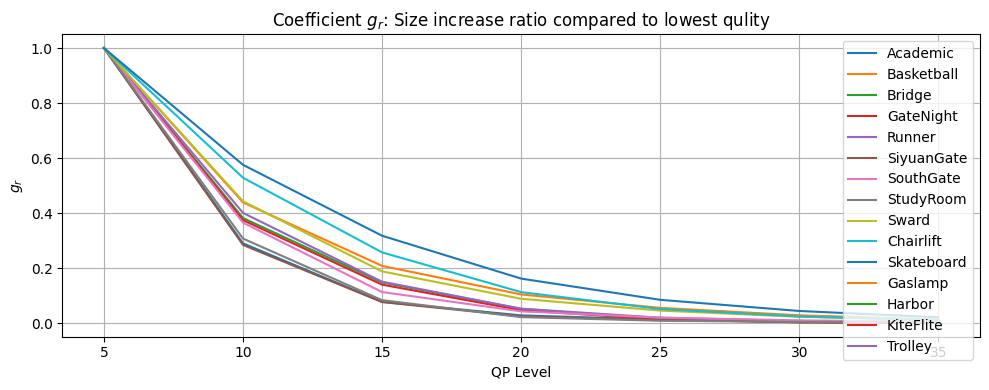

array([[[1.00000000e+00, 2.90964410e-01, 7.88778055e-02, 2.93907115e-02,
         1.43513821e-02, 7.48769564e-03, 4.17008035e-03],
        [0.00000000e+00, 1.87747931e-02, 7.90889190e-03, 1.98716193e-03,
         6.13816686e-04, 2.08628946e-04, 9.02956084e-05]],

       [[1.00000000e+00, 4.39495744e-01, 2.09173127e-01, 1.05451237e-01,
         5.67421087e-02, 2.97311861e-02, 1.46526075e-02],
        [0.00000000e+00, 2.87720310e-02, 2.43173339e-02, 1.60247238e-02,
         9.81657556e-03, 5.59099969e-03, 2.85438570e-03]],

       [[1.00000000e+00, 3.82729347e-01, 1.49280175e-01, 5.30569086e-02,
         1.59372596e-02, 4.45004937e-03, 1.88348068e-03],
        [0.00000000e+00, 3.51246357e-03, 2.27606231e-03, 1.20189054e-03,
         4.85714800e-04, 1.84984837e-04, 6.69644259e-05]],

       [[1.00000000e+00, 3.75111556e-01, 1.41017252e-01, 4.82472561e-02,
         1.45243717e-02, 4.43320705e-03, 2.07998555e-03],
        [0.00000000e+00, 5.61922323e-03, 3.00953866e-03, 1.61230762e-03,
    

In [29]:
from src.plotting.plotting_utils import plot_gr
gr_values = plot_gr(video_bitrates, video_names[:], qp_labels, ylabel='$g_r$', title="Coefficient $g_r$: Size increase ratio compared to lowest qulity")
len(video_bitrates)
gr_values

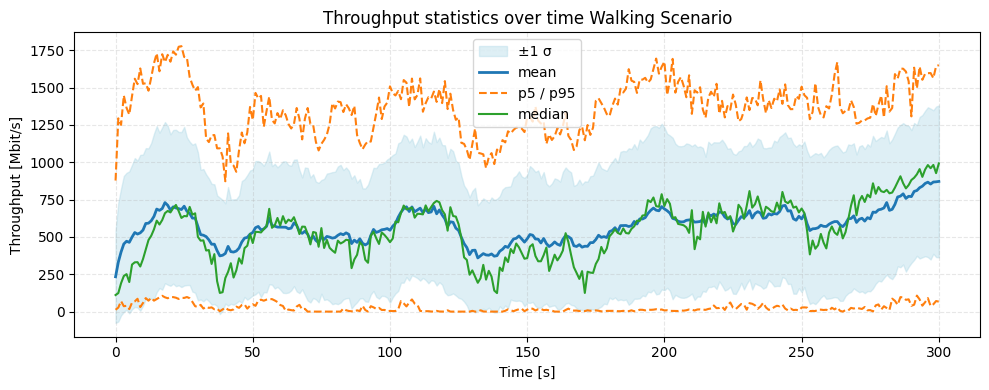

               mean         std  median   p05     p95
time_ms                                              
0.0      233.306667  308.805150   111.0  12.4   877.4
1.0      331.186667  397.562733   124.0  27.0  1294.0
2.0      398.906667  423.935556   190.0  70.3  1250.0
3.0      452.746667  454.988449   238.0  36.2  1447.0
4.0      471.066667  457.655079   251.0  38.8  1364.0


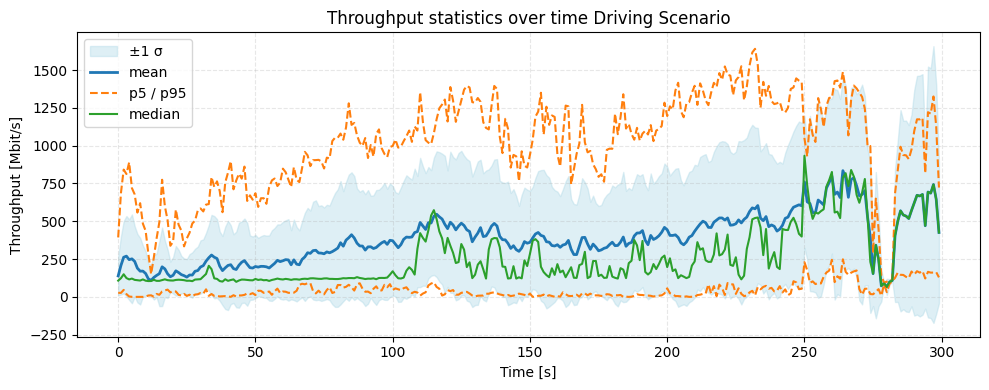

               mean         std  median    p05     p95
time_ms                                               
0.0      138.586957  128.673847   107.5  27.25  393.25
1.0      207.673913  191.966902   123.5  26.25  686.50
2.0      262.152174  239.213802   149.5  46.25  841.75
3.0      269.456522  265.029953   124.5  18.50  812.50
4.0      246.152174  266.234814   115.5   2.25  889.50


In [8]:
import os
from src.plotting.network_traces_utils import load_scenario_files, multi_stats, plot_multi_traces, plot_tx_times_per_qp, plot_time_stats

_5g_data_path = "datasets/Network-Traces/Lumous5G/5G"
_4g_data_path = "datasets/Network-Traces/Lumous5G/4G"

files = os.listdir(_5g_data_path)

walking_traces_path = list(filter(lambda x: 'walking' in x, files))
driving_traces_path = list(filter(lambda x: 'driving' in x, files))

walking_traces_path = ["%s/%s" % (_5g_data_path, f_name) for f_name in walking_traces_path]
driving_traces_path = ["%s/%s" % (_5g_data_path, f_name) for f_name in driving_traces_path]


stats_df = plot_time_stats(walking_traces_path,
                           bin_size_s=1.0,
                           align_start=True,  # each trace starts at 0 s
                           max_duration_s=300,  # compare first 5 min only
                           title="Throughput statistics over time Walking Scenario")
print(stats_df.head())  # numerical table if you need it


stats_df = plot_time_stats(driving_traces_path,
                           bin_size_s=1.0,
                           align_start=True,  # each trace starts at 0 s
                           max_duration_s=300,  # compare first 5 min only
                           title="Throughput statistics over time Driving Scenario")
print(stats_df.head())  # numerical table if you need it



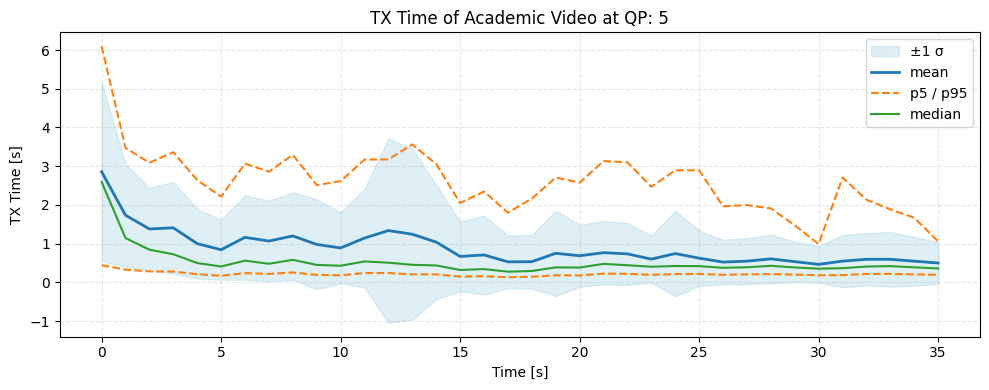

In [9]:
from src.plotting.network_traces_utils import load_net_trace
from src.plotting.viewport import compute_tx_times

video_idx = 0
qp_idx = 0

tx_times = []
for net_path in walking_traces_path:
    net_df = load_net_trace(net_path)
    tx = compute_tx_times(video_bitrates[video_idx][qp_idx], net_df)
    tx_times.append(tx)

tx_times = pd.DataFrame(tx_times)
# print(tx_times.head())

mean = tx_times.mean(axis=0)
std  = tx_times.std(axis=0)
p05  = tx_times.quantile(0.05, axis=0)
p95  = tx_times.quantile(0.95, axis=0)
median = tx_times.quantile(0.5, axis=0)

t = list(range(tx_times.shape[1]))

plt.figure(figsize=(10, 4))
# mean ± std band
plt.fill_between(t, mean-std, mean+std,
                 color='lightblue', alpha=0.4,
                 label="±1 σ")
# mean
plt.plot(t, mean, color='tab:blue', linewidth=2.0, label="mean")
# p5 / p95
plt.plot(t, p05, color='tab:orange', linestyle="--", label="p5 / p95")
plt.plot(t, p95, color='tab:orange', linestyle="--")
# median
plt.plot(t, median, color='tab:green', linewidth=1.5, label="median")

plt.xlabel("Time [s]")
plt.ylabel("TX Time [s]")
plt.title(f'TX Time of {video_names[video_idx]} Video at QP: {qp_labels[qp_idx]}')
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
from scipy import stats
qp_idx = 4
stats = []
for i, v_bitrate in enumerate(video_bitrates):
    data = v_bitrate[qp_idx]
    mean = data.mean(axis=0)
    std  = data.std(axis=0)
    p05  = np.quantile(data, 0.05, axis=0)
    p95  = np.quantile(data, 0.95, axis=0)
    median = np.quantile(data, 0.5, axis=0)
    stats.append((video_names[i], mean, std, p05, p95, median))
    
pd.DataFrame(stats).shape


(10, 6)

In [11]:
bitrate[0].shape

(7, 64, 1080)

(9, 36)


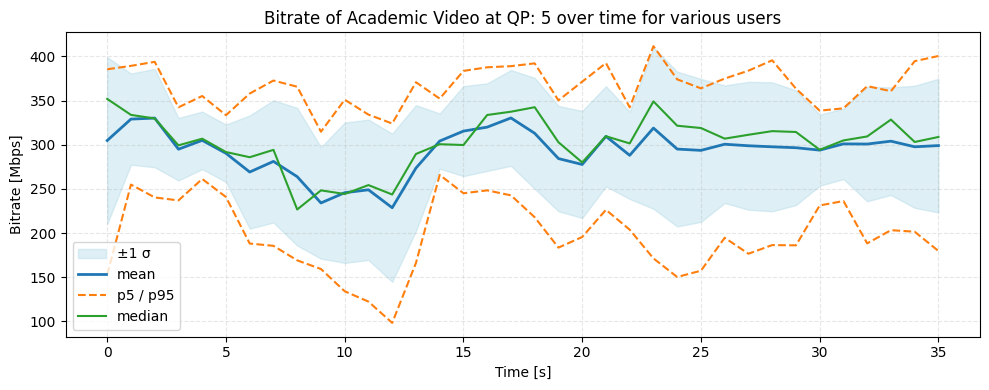

In [12]:
video_idx = 0
qp_idx = 0
user_traces = {}
for u_id in range(10):
    u_trace = build_fov_traces(bitrate[video_idx], ymse[video_idx], hmd[video_idx][u_id], bitdepth[video_idx])  # shape (7, N)
    # print(u_trace['bitrate'].shape)
    
    if len(u_trace['bitrate'][0]) > 0:
        # print(u_trace['bitrate'].shape)
        # print(hmd[video_idx][u_id].shape)
        user_traces[u_id] = u_trace

user_bitrates = [item['bitrate'] for k, item in user_traces.items()]

data = np.array(user_bitrates)[:, qp_idx] / 1e6

print(data.shape)
mean = data.mean(axis=0)
std  = data.std(axis=0)
p05  = np.quantile(data, 0.05, axis=0)
p95  = np.quantile(data, 0.95, axis=0)
median = np.quantile(data, 0.5, axis=0)

t = list(range(mean.shape[0]))

plt.figure(figsize=(10, 4))
# mean ± std band
plt.fill_between(t, mean-std, mean+std,
                 color='lightblue', alpha=0.4,
                 label="±1 σ")
# mean
plt.plot(t, mean, color='tab:blue', linewidth=2.0, label="mean")
# p5 / p95
plt.plot(t, p05, color='tab:orange', linestyle="--", label="p5 / p95")
plt.plot(t, p95, color='tab:orange', linestyle="--")
# median
plt.plot(t, median, color='tab:green', linewidth=1.5, label="median")

plt.xlabel("Time [s]")
plt.ylabel("Bitrate [Mbps]")
plt.title(f'Bitrate of {video_names[video_idx]} Video at QP: {qp_labels[qp_idx]} over time for various users')
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



0    0.026668
1    0.140142
2    0.626297
3    1.863740
4    3.707892
5    7.839819
6         NaN
Name: 0, dtype: float64


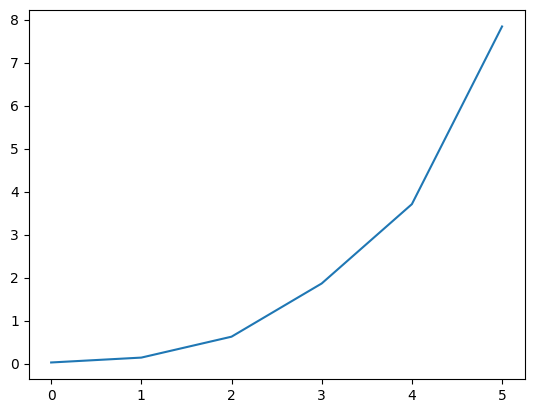

In [13]:
# Local Computation
rho = .7
g_r_star = .7
mu_s = np.array([250, 300, 350, 400, 450, 500]) * 1e6
f_vr = 2.4e9
kappa = 1e-27
L = (rho * g_r_star * mu_s) / f_vr
E = kappa * rho * mu_s * g_r_star * f_vr**2

L_star = (rho * mu_s) / f_vr
E_star = kappa * rho * mu_s * f_vr**2

delta_q = pd.DataFrame(avg_psnr).diff(-1, axis=1)
# print(delta_q)

delta_g = pd.DataFrame(gr_values[:, 0, :]).diff(-1, axis=1)
delta_q / delta_g
trade_off = L_star[0] / delta_q / delta_g
print(trade_off.loc[0])

plt.figure()
plt.plot(trade_off.loc[0])
plt.show()

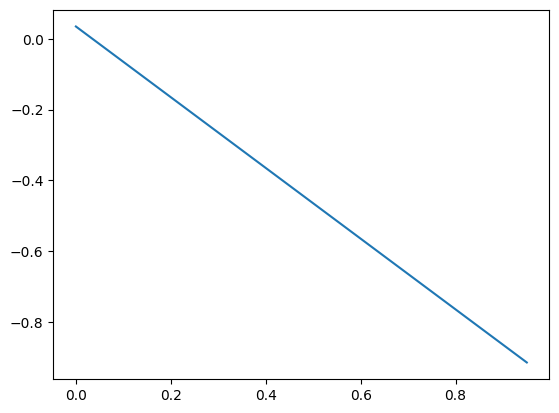

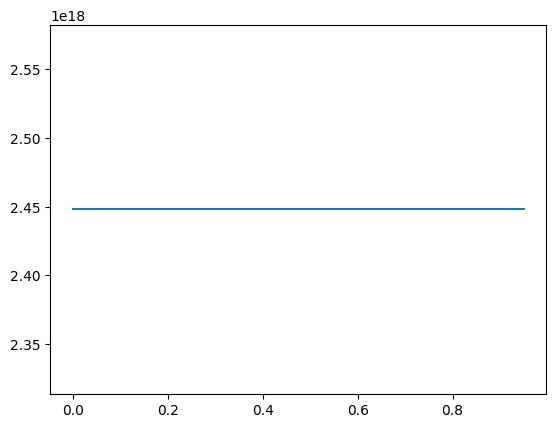

In [14]:
g_r = np.arange(0, 1, 0.05)
rho = 1.
d = 300e6
f_vr = 2.4e9
f_es = 3.4e9

kappa = 1e-27
e_rx = 5.97 * 1e-9

latency_condition = ((1-g_r) / rho) - (d / ((f_vr - f_es)/(f_vr*f_es)))

energy_condition = ((1-g_r) / rho) - (kappa * f_vr * f_vr) / (e_rx)

plt.figure()
plt.plot(g_r, energy_condition)
plt.show()

plt.figure()
plt.plot(g_r, latency_condition)
plt.show()